In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba
import torch
torch.set_grad_enabled(False)

/iridisfs/home/lhl1g23/ssm/mamba


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
from models.dataloaders.selective_copying import generate_dataset
from models.configs.selective_copying.config import training_config, dataset_config, MambaConfig
from models.selective_copying_mamba import validate
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
import matplotlib.pyplot as plt
import torch

X, y = generate_dataset(dataset_config, training_config)
X, y = X.to("cuda"), y.to("cuda")

model = MambaLMHeadModel(MambaConfig, device="cuda")
model.load_state_dict(torch.load("/scratch/lhl1g23/mamba/checkpoints/selective_copying.pt", weights_only=True))

pred = model(X, num_last_tokens=dataset_config['l_memorize']).logits.argmax(1)

/home/lhl1g23/.conda/envs/mamba/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
hidden_states = model.backbone.embedding(X[:1])
A, B, C, D, dt, dA, dB, states, y_ssm = model.backbone.layers[1].mixer.get_parameters(hidden_states)

/tmp/ipykernel_3847438/3346384580.py:15: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  v = torch.var(window_data, dim=0).mean()


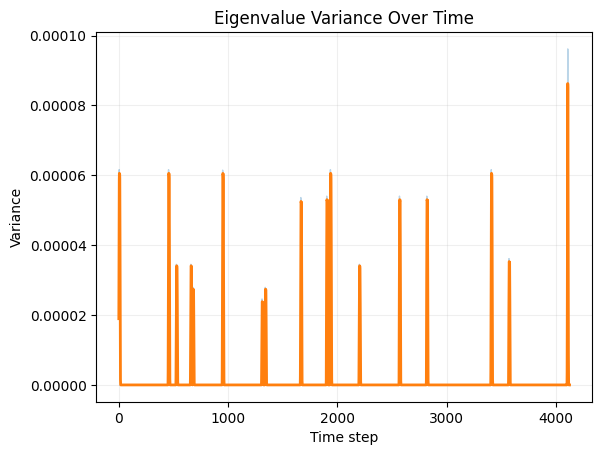

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_variance(M, ax, b_dim, window=100):
    M = M[b_dim]
    l = len(M)

    reshaped = M.reshape(l, -1)
    variances = []

    for t in range(l):
        start = t
        end = min(l, t + window)
        window_data = reshaped[start:end, :]
        v = torch.var(window_data, dim=0).mean()
        variances.append(v)
        

    x = np.arange(len(variances))

    kernel = np.ones(5) / 5
    smooth = np.convolve(variances, kernel, mode="same")

    ax.plot(x, variances, alpha=0.3, linewidth=1)
    ax.plot(x, smooth, linewidth=2)

    ax.set_xlabel("Time step")
    ax.set_ylabel("Variance")
    ax.set_title("Eigenvalue Variance Over Time")

    ax.grid(alpha=0.2)
plot_variance(dA, plt.gca(), 0, window=10)

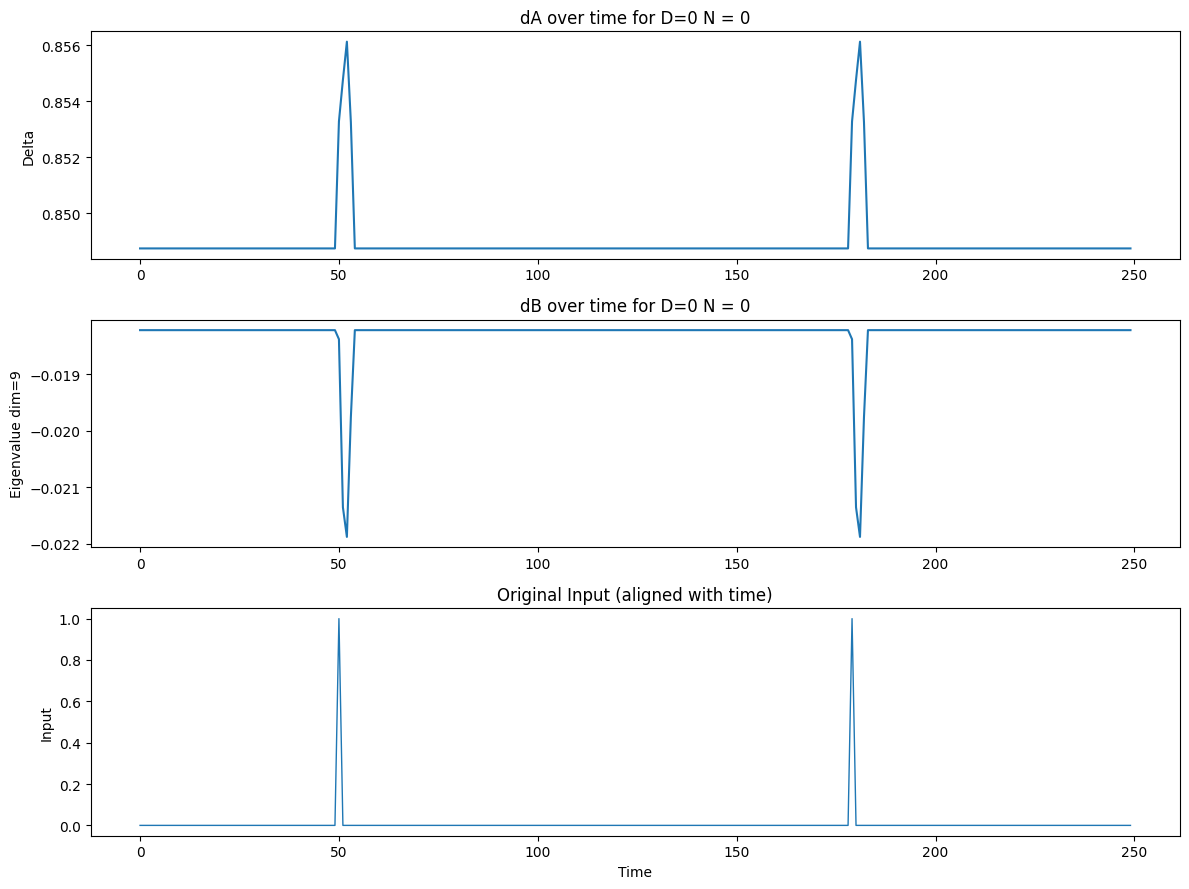

In [50]:
import matplotlib.pyplot as plt
import torch

sample = 0
start = 0
n_din = 128
D, N = 0,0

with torch.no_grad():
    b,l,d,n = dA.shape
    
    fig = plt.figure(figsize=(12,9))
    gs = fig.add_gridspec(3, 1, height_ratios=[3,3,3])
    
    ax0 = fig.add_subplot(gs[0,0])
    ax1 = fig.add_subplot(gs[1,0])
    ax_input = fig.add_subplot(gs[2,0], sharex=ax0)  
    
    #for i in range(start, start + n_din):
    ax0.plot(dA[sample, :, D, N][250:500])
    ax0.set_title(f"dA over time for D={D} N = {N}")
    ax0.set_ylabel("Delta")
    
    #for i in range(start, start + n_din):
    ax1.plot(dB[sample, :, D, N][250:500])
    ax1.set_title(f"dB over time for D={D} N = {N}")
    ax1.set_ylabel("Eigenvalue dim=9")

    x = (X != 0).int().to('cpu')[sample]
    ax_input.plot(x[250:500], linewidth=1.0)
    ax_input.set_title("Original Input (aligned with time)")
    ax_input.set_xlabel("Time")
    ax_input.set_ylabel("Input")
    
    plt.tight_layout()
    plt.show()


In [13]:
import numpy as np
def plot_real_eigen(x, title="Real eigenvalues", s=1, alpha=0.9, grid=True):
    t = np.arange(len(x))

    fig, ax = plt.subplots()

    ax.scatter(t, x, marker='o', linewidth=1.5,
            alpha=alpha, label="values", s=s)

    ax.axhline(y=1, linestyle='--', linewidth=1.2,
               color="gray", alpha=0.8, label="y = 1")

    ax.set_xlabel("Index", fontsize=11)
    ax.set_ylabel("Value", fontsize=11)
    ax.set_title(title, fontsize=13, weight="bold")

    ax.set_ylim(0, max(1.1, np.max(x) + 0.1))

    if grid:
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_alpha(0.6)

    ax.legend(frameon=False, fontsize=9, loc="lower left")

    plt.tight_layout()
    plt.show()

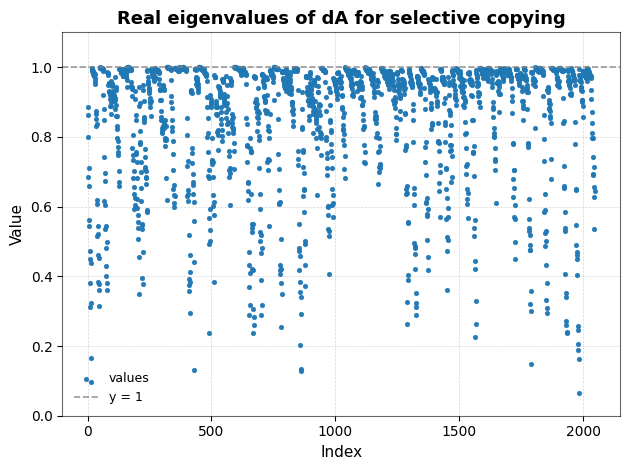

In [16]:
plot_real_eigen(torch.flatten(dA[0, 0, :, :].cpu()).numpy(), title="Real eigenvalues of dA for selective copying", s=5)
plt.show()

In [44]:
X[sample][299:310]

tensor([ 0, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0], device='cuda:0')

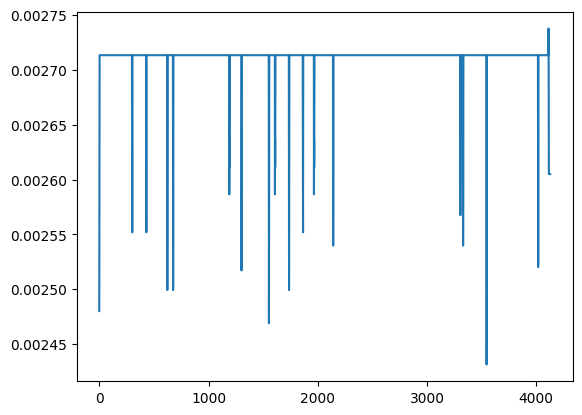

In [33]:
plt.plot(dt[sample, :, D])

In [26]:
X[sample][299:310]

tensor([ 0, 13,  0,  0,  0,  0,  0,  0,  0,  0,  0], device='cuda:0')

In [62]:
x.shape

torch.Size([64, 4128])

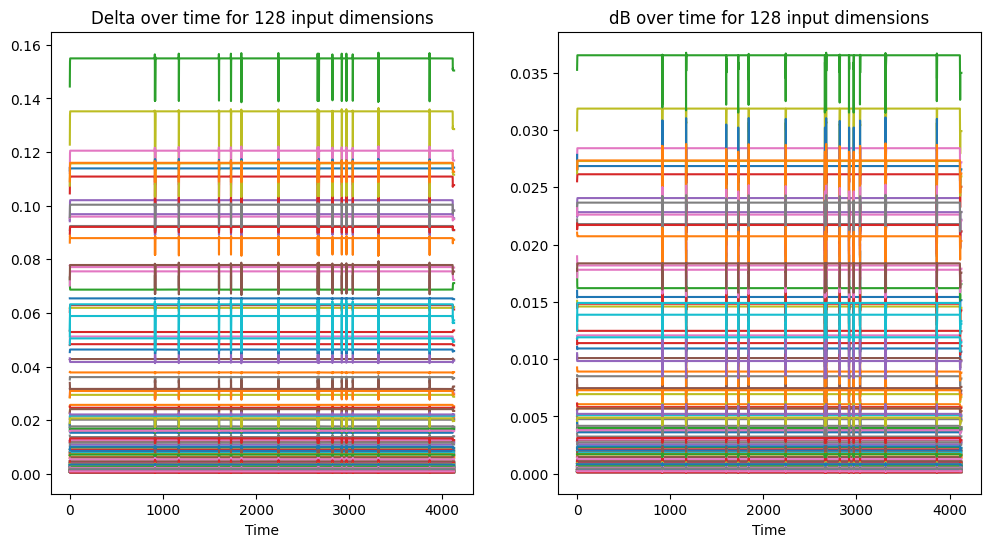

In [8]:
start = 0
n_din = 128
fig, ax = plt.subplots(1,2, figsize=(12,6))

with torch.no_grad():
    b,l,d,n = dB.shape
    for i in range(start, start + n_din):
        y_axis = dt[sample,:,i]
        ax[0].plot(y_axis)
            
    for i in range(start, start + n_din):
        y_axis = dB[sample,:,i,5]
        ax[1].plot(y_axis)

ax[0].set_xlabel("Time")
ax[0].set_title(f"Delta over time for {n_din} input dimensions")
ax[1].set_xlabel("Time")
ax[1].set_title(f"dB over time for {n_din} input dimensions")
plt.show()

In [41]:
dA.shape

torch.Size([2, 4128, 128, 16])

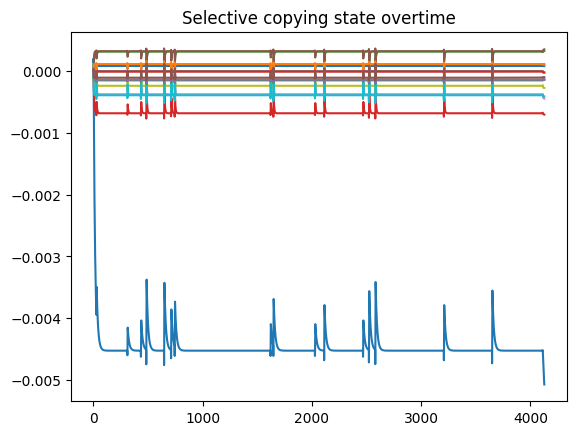

In [113]:
with torch.no_grad():
    plt.plot(states[1,:,0,:])
    plt.title("Selective copying state overtime")

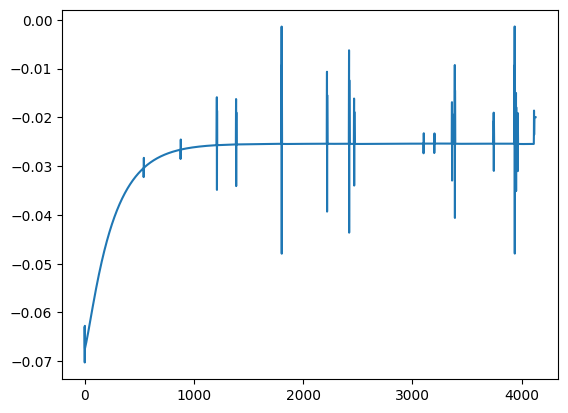

In [ ]:
with torch.no_grad():
    plt.plot(y_ssm[0,:,3])

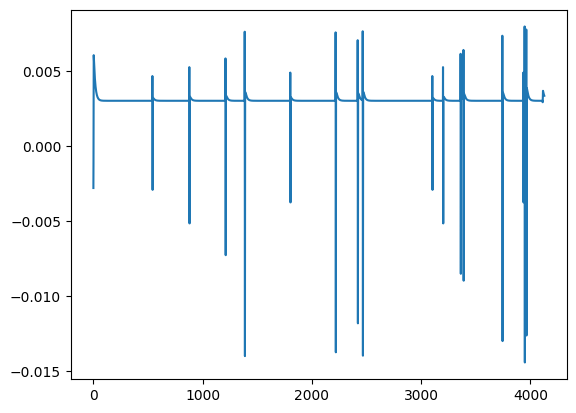

In [107]:
plt.plot(y_ssm[0,:,0])

In [112]:
model(X).logits.shape

AttributeError: 'Delete' object has no attribute 'value'

torch.Size([64, 4128, 16])

In [68]:
pred = model(X)

In [71]:
pred.logits.shape

torch.Size([64, 4128, 16])

In [11]:
mask = (X != 0) & (X != 15)
idx = torch.nonzero(mask)  


batch_idx, seq_idx = idx[:, 0], idx[:, 1]
counts = torch.bincount(batch_idx, minlength=X.shape[0])

grouped_indices = torch.split(seq_idx, counts.tolist())

grouped_indices = torch.tensor([g.tolist() for g in grouped_indices])

In [26]:
grouped_indices[0]

tensor([ 540,  878, 1209, 1385, 1802, 2217, 2419, 2465, 3102, 3200, 3361, 3387,
        3743, 3935, 3947, 3962])

In [28]:
X[0,541]

tensor(0, device='cuda:0')

In [10]:
dt_mean = torch.mean(dt[sample], dim=1)

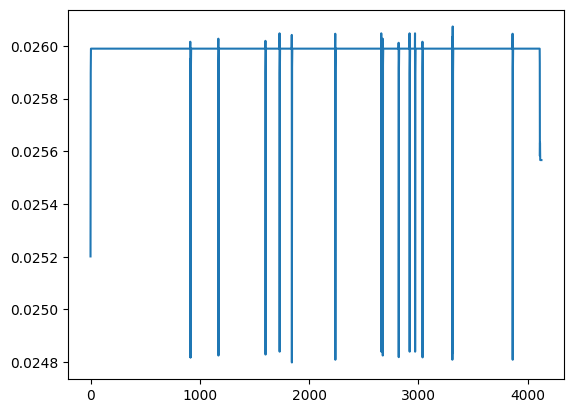

In [15]:
plt.plot(dt_mean)